# **Gavan Rewt - Capstone Project**

## Objectives

* Explore data in order to investigate how do North Pacific humpback whale observations in the North Pacific region vary by season and sea-surface temperature between 2010 and 2025?

## Inputs

* The data I obtained this data from the OBIS website. This has been saved as whale_data_original.csv
* the inputs used are Pandas, Numpy, Matplotlb, Seaborn, Sci-Kit Learn


## Outputs

* By the end of the notebook there will be
1. A cleaned dataset called whale_data_cleaned.csv
2. A streamlit app that will feature the dashboard created on tableau and will allow you to make predictions about the sea surface temperatures.

## Additional Comments

* This project was inspired by a recent trip to Alaska, where I had the opportunity to see humpback whales in their natural environment whilst on a boat tour. This experience sparked my interest in learning more about their seasonal patterns and the environmental conditions associated with their sightings. Using North Pacific humpback whale observation data, this project explores how recorded observations vary by season and sea-surface temperature between 2010 and 2025.



---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [6]:
import os
current_dir = os.getcwd()
current_dir

'/Users/gavrewt/Documents/VS Code Projects/Capstone Project/jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [7]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [8]:
current_dir = os.getcwd()
current_dir

'/Users/gavrewt/Documents/VS Code Projects/Capstone Project'

# Section 1 - Cleaning the data

In this section i will be using pandas to clean to the data

In [9]:
import pandas as pd

Firstly I will load the csv file and check the first 5 rows of the data

In [10]:
# loading the original dataset
from pathlib import Path

candidate_paths = [
    Path.cwd() / 'whale_data_original.csv',
    Path.cwd().parent / 'whale_data_original.csv',
]

csv_path = next((path for path in candidate_paths if path.exists()), None)

if csv_path is None:
    raise FileNotFoundError(
        'Could not find whale_data_original.csv in the current folder or its parent.'
    )

df = pd.read_csv(csv_path)

print(df.head(5))

/var/folders/cx/hq4jzbks3blc8b79k9pk2_8r0000gn/T/ipykernel_11260/3577022494.py:16: DtypeWarning: Columns (4,7,16,17,20,23,24,25,28,29,30,33,34,35,50,59,60,61,62,66,69,78,79,80,81,82,83,88,89,90,96,97,98,99,101,112,113,118,124,125,127,128,129,135,145,147,148,149,153,155,156,160,163,164,168,169,170,183,185,186,187,190,191,192,194,195,197,201,205,209,240,249,251,252,255,260,264,265,267,268,269,270,274,275) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)


                             dataset_id                                    id  \
0  02c8f47f-7f7d-4d91-aefa-cf2091d766a2  8eb922af-18a3-4cab-9886-161a7c725bcd   
1  02c8f47f-7f7d-4d91-aefa-cf2091d766a2  a7dda06a-dd59-4a91-b108-3208206965a5   
2  02c8f47f-7f7d-4d91-aefa-cf2091d766a2  4e8f1c09-3e68-44f3-9721-d9b595f0e52d   
3  02c8f47f-7f7d-4d91-aefa-cf2091d766a2  38d6ddef-6eb9-4ea1-a9e5-1ab771675a60   
4  02c8f47f-7f7d-4d91-aefa-cf2091d766a2  2d9d6726-d5e2-4801-a584-fa79b7a28850   

   acceptedNameUsage  acceptedNameUsageID accessRights  aphiaid  \
0                NaN                  NaN          NaN   137092   
1                NaN                  NaN          NaN   137092   
2                NaN                  NaN          NaN   137092   
3                NaN                  NaN          NaN   137092   
4                NaN                  NaN          NaN   137092   

                      areas associatedMedia  associatedOccurrences  \
0  [266, 268, 40010, 31908]             

Now the data will be cleaned. 
There are 282 columns in this dataset, which I do not need to use them all to investigate my question. 
I have consulted an AI assistant to help me identify the columns that are relevant to my question and initial exploration. 
These columns are
occuranceID, eventDate, date_year, month, decimalLattitude decimalLongitude, sst, sss, datasetName, BasisOfrecord and coordinateUncertaintyIn Meters.
due to this leavng a large columns that I do not need to use, I have consulted a variety of blogs to look at the best way of dropping these unwanted columns 
After reading this blog https://medium.com/@whyamit101/pandas-only-keep-certain-columns-7710d6f71a56 - I have found I can keep selected columns by their names
I will be calling this as df_selected and will be using the following code to select the columns I need. 


In [11]:
# Creating a dataframe with selected columns from the original dataframe
df_selected = df[['occurrenceID', 'eventDate', 'date_year', 'month', 'decimalLatitude', 'decimalLongitude', 'sst', 'sss', 'datasetName', 'basisOfRecord', 'coordinateUncertaintyInMeters']]
print(df_selected.head(5))

  occurrenceID            eventDate  date_year  month  decimalLatitude  \
0       924_10  2011-02-24T09:19:00       2011    2.0        22.030550   
1       924_12  2011-02-24T09:29:00       2011    2.0        21.907300   
2       924_19  2011-02-24T09:36:00       2011    2.0        21.798717   
3       924_86  2011-02-26T09:53:24       2011    2.0        21.907100   
4       924_47  2011-02-26T08:54:36       2011    2.0        22.122583   

   decimalLongitude    sst    sss  \
0       -160.086933  25.51  35.11   
1       -160.225183  25.58  35.10   
2       -160.190800  25.59  35.09   
3       -160.065783  25.55  35.11   
4       -159.285400  25.26  35.17   

                                      datasetName     basisOfRecord  \
0  HRC SCC Aerial Shoreline Surveys February 2011  HumanObservation   
1  HRC SCC Aerial Shoreline Surveys February 2011  HumanObservation   
2  HRC SCC Aerial Shoreline Surveys February 2011  HumanObservation   
3  HRC SCC Aerial Shoreline Surveys February 201

I will now check the datatypes of the columns in the dataframe to ensure that they are correct.

In [12]:
# Checking the data types: 
print ("Checking data types of columns:")
print (df_selected.dtypes)

Checking data types of columns:
occurrenceID                      object
eventDate                         object
date_year                          int64
month                            float64
decimalLatitude                  float64
decimalLongitude                 float64
sst                              float64
sss                              float64
datasetName                       object
basisOfRecord                     object
coordinateUncertaintyInMeters    float64
dtype: object


Due to the datatypes, I will now convert them in order for the eventDate contains dates recorded with different levels of detail.

The format="mixed" will be used to allow pandas to interpret the different ISO date formats.

Invalid dates will be converted to NaT, meaning "Not a Time".

The date is required for the time-based analysis I will now remove any n/a values from the eventDate column.

The then convert columns that should contain numerical data. errors="coerce" changes values that cannot be converted into NaN.

Then there will be a conversion of text-based columns to the pandas string data type.

finally a check will be done showing that the data types have been converted

I will then Check whether the conversion created any additional missing values


In [13]:
#Creating date time object for eventDate column and dropping rows with missing eventDate values
df_selected["eventDate"] = pd.to_datetime( df_selected["eventDate"],format="mixed", errors="coerce",utc=True)
#Dropping rows with missing eventDate values
df_selected = df_selected.dropna(subset=['eventDate'])
# Checking the data types after conversion
print ("Selected data after dropping rows with missing eventDate values:")
print (df_selected.head(5))
# Converting the numeric columns to numeric data types and the text columns to string data types
numeric_columns = ["date_year","month","decimalLatitude","decimalLongitude","sst","sss","coordinateUncertaintyInMeters"]

for column in numeric_columns:
    df_selected[column] = pd.to_numeric(df_selected[column],errors="coerce")

text_columns = ["occurrenceID","datasetName","basisOfRecord"]

for column in text_columns:
    df_selected[column] = df_selected[column].astype("string")

print("\nChecking data types after conversion:")
print(df_selected.dtypes)

print("\nMissing values after datatype conversion:")
print(df_selected.isnull().sum())


Selected data after dropping rows with missing eventDate values:
  occurrenceID                 eventDate  date_year  month  decimalLatitude  \
0       924_10 2011-02-24 09:19:00+00:00       2011    2.0        22.030550   
1       924_12 2011-02-24 09:29:00+00:00       2011    2.0        21.907300   
2       924_19 2011-02-24 09:36:00+00:00       2011    2.0        21.798717   
3       924_86 2011-02-26 09:53:24+00:00       2011    2.0        21.907100   
4       924_47 2011-02-26 08:54:36+00:00       2011    2.0        22.122583   

   decimalLongitude    sst    sss  \
0       -160.086933  25.51  35.11   
1       -160.225183  25.58  35.10   
2       -160.190800  25.59  35.09   
3       -160.065783  25.55  35.11   
4       -159.285400  25.26  35.17   

                                      datasetName     basisOfRecord  \
0  HRC SCC Aerial Shoreline Surveys February 2011  HumanObservation   
1  HRC SCC Aerial Shoreline Surveys February 2011  HumanObservation   
2  HRC SCC Aerial Shorel

/var/folders/cx/hq4jzbks3blc8b79k9pk2_8r0000gn/T/ipykernel_11260/1565970822.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_selected["eventDate"] = pd.to_datetime( df_selected["eventDate"],format="mixed", errors="coerce",utc=True)


This shows 3628 values in the original month column do not agree with eventDate.
As eventDate contains the complete observation date, I will derive the month directly from eventDate to make the date information consistent.

df_selected["month"] = df_selected["eventDate"].dt.month

month_mismatches = df_selected[ df_selected["eventDate"].dt.month != df_selected["month"]]

print("Month mismatches after correction:",len(month_mismatches))

I want to create a new column called season which will be based on the month column. 
Month 1 will be January and be categorised as winted and month 12 will be categorised as winter. 
The Royal meterorigical society catergorises the seasons as follows: 
Winter: December, January, February
Spring: March, April, May
Summer: June, July, August
Autumn: September, October, November

source: https://www.rmets.org/metmatters/difference-between-meteorological-and-astronomical-seasons\

In [14]:
# Creating Seasons
df_selected['season'] = df_selected['month'].apply(lambda x: 'Winter' if x in [12, 1, 2] else ('Spring' if x in [3, 4, 5] else ('Summer' if x in [6, 7, 8] else 'Autumn')))
print ("Selected data after creating season column:")
print (df_selected.head(5))

Selected data after creating season column:
  occurrenceID                 eventDate  date_year  month  decimalLatitude  \
0       924_10 2011-02-24 09:19:00+00:00       2011    2.0        22.030550   
1       924_12 2011-02-24 09:29:00+00:00       2011    2.0        21.907300   
2       924_19 2011-02-24 09:36:00+00:00       2011    2.0        21.798717   
3       924_86 2011-02-26 09:53:24+00:00       2011    2.0        21.907100   
4       924_47 2011-02-26 08:54:36+00:00       2011    2.0        22.122583   

   decimalLongitude    sst    sss  \
0       -160.086933  25.51  35.11   
1       -160.225183  25.58  35.10   
2       -160.190800  25.59  35.09   
3       -160.065783  25.55  35.11   
4       -159.285400  25.26  35.17   

                                      datasetName     basisOfRecord  \
0  HRC SCC Aerial Shoreline Surveys February 2011  HumanObservation   
1  HRC SCC Aerial Shoreline Surveys February 2011  HumanObservation   
2  HRC SCC Aerial Shoreline Surveys February 

The seasons are correct.
i will now check the unique values in the season column to ensure that they are all valid seasons


In [15]:
print("Season values:", sorted(df_selected["season"].unique()))

Season values: ['Autumn', 'Spring', 'Summer', 'Winter']


From the above you can see that there are only the correct seasons being used. 
I intend to plot the coordinates on a map to highlight the locations of the observations when doing the dashboard on tableau.
I must check the coordinates to ensure that they are valid.
I will check the maximum and minimumn values in the decimalLatitude column to ensure that they are all valid
After running the code you will find that the Latitude must between -90 and 90 and Longitude must be between -180 and 180
It will then check for any invalid coordinates and any missing coordinates. 

In [16]:
# Check the latitude range in the SST dataset
print("Minimum latitude:", df_selected["decimalLatitude"].min())
print("Maximum latitude:", df_selected["decimalLatitude"].max())

# Check the longitude range in the SST dataset
print("Minimum longitude:", df_selected["decimalLongitude"].min())
print("Maximum longitude:", df_selected["decimalLongitude"].max())

# Latitude must be between -90 and 90.
# Longitude must be between -180 and 180.
invalid_coordinates = df_selected[ ~df_selected["decimalLatitude"].between(-90, 90) | ~df_selected["decimalLongitude"].between(-180, 180) ]
print("Invalid coordinates:", len(invalid_coordinates))

#i will now check for any missing coordinates in the decimalLatitude and decimalLongitude columns
print(df_selected[["decimalLatitude", "decimalLongitude"]].isnull().sum())

Minimum latitude: 1.9e-05
Maximum latitude: 58.100267
Minimum longitude: -178.393
Maximum longitude: 173.995765
Invalid coordinates: 0
decimalLatitude     0
decimalLongitude    0
dtype: int64


I will now export the cleaned dataframe to a new csv file


In [17]:
df_selected.to_csv('whale_data_cleaned.csv', index=False)

---

# Section 2: Exploration of the data using Numpy

To start section 2. NumPy is required to explore the data. 
This means that the first step is to install NumPy.

In [18]:
import numpy as np

Firstly this section will begin by creating separate dataframes for the SST and SSS analysis to ensure that no data is lost from the original dataframe during any manipulation.

To do this any n/a values for SST and SSS will be dropped from each dataframe. This will take steps to work towards my goal of predicting sea surface temperature using SciKitLearn. 

The code then excludes missing measurements without changing the dataframes selected

Finally two new arrays will be created for analysis


In [19]:
# Dropping any rows with missing values in the sst and sss columns to create separate dataframes for analysis
df_sst = df_selected.dropna(subset=['sst']).copy()
df_sss = df_selected.dropna(subset=['sss']).copy()
# Printing the number of cleaned observations, observations with sst data, and observations with SSS data
print ("Total cleaned observations:", len(df_selected))
print ("observations with sst data:", len(df_sst))
print ("observations with SSS data:", len(df_sss))

# The sst and sss columns will now be converted to numpy arrays for analysis
sst_array = df_sst['sst'].to_numpy()
sss_array = df_sss['sss'].to_numpy()

Total cleaned observations: 129314
observations with sst data: 124618
observations with SSS data: 124618


First for exploration will be the Sea Surface Temperature (SST) dataframe. 
The code will identify the mean temperature, median temperature as well as identifying the maximum and minimum sst. 
Finally the standard deviation of the sea surface will be calculated. 


In [20]:
print("sea-surface temperature (sst) analysis:")
print ("Mean sst:", np.mean(sst_array))
print ("median sst:", np.median(sst_array))
print ("maximum sst:", np.max(sst_array))
print ("minimum sst:", np.min(sst_array))
print(f"Standard deviation of sst: {np.std(sst_array):.2f}")

sea-surface temperature (sst) analysis:
Mean sst: 19.00390689948482
median sst: 16.91
maximum sst: 29.46
minimum sst: 4.73
Standard deviation of sst: 6.40


The standard deviation of SST is approximately 6.40°C.
This shows that the SST values are fairly spread out around the mean.
The variation may be influenced by differences in season, year and geographical location, which as this data covers the entire north pacific region, makes sense. 

It will be beneficial to explore the seasonal variation between these values which will serve as a useful comparison. 
A function has been created that will orunt the data for each individual season. 

In [21]:
season_order = ["Winter", "Spring", "Summer", "Autumn"]

for season in season_order:

    season_sst = df_sst.loc[df_sst["season"] == season,"sst"].to_numpy()

    print("\nSeason:", season)
    print("Number of observations:", len(season_sst))
    print("Mean SST:", np.mean(season_sst))
    print("Median SST:", np.median(season_sst))
    print("Minimum SST:", np.min(season_sst))
    print("Maximum SST:", np.max(season_sst))
    print(f"Standard deviation of sst: {np.std(season_sst):.2f}")


Season: Winter
Number of observations: 44134
Mean SST: 24.81455385870304
Median SST: 25.38
Minimum SST: 10.48
Maximum SST: 29.46
Standard deviation of sst: 3.13

Season: Spring
Number of observations: 25653
Mean SST: 19.66801348770124
Median SST: 24.8
Minimum SST: 6.79
Maximum SST: 29.13
Standard deviation of sst: 6.24

Season: Summer
Number of observations: 26191
Mean SST: 14.188178000076363
Median SST: 12.78
Minimum SST: 4.73
Maximum SST: 28.76
Standard deviation of sst: 4.37

Season: Autumn
Number of observations: 28640
Mean SST: 13.858841829608938
Median SST: 12.78
Minimum SST: 5.18
Maximum SST: 29.11
Standard deviation of sst: 3.31


The seasonal SST results show clear differences in the temperatures associated with recorded humpback whale observations throughout the year.

Winter had the highest number of recorded observations (38,034) and also the highest mean SST at approximately 24.36°C, with a median SST of 25.38°C. This suggests that many winter whale observations were recorded in relatively warm waters.

Spring had 23,572 observations and a mean SST of approximately 19.11°C. The standard deviation was 6.26°C, which was the highest of all four seasons. This indicates that spring observations occurred across a particularly wide range of sea-surface temperatures.

Summer had 26,678 observations and a lower mean SST of approximately 14.43°C,with a median of 12.78°C. This suggests that many summer observations were recorded in cooler waters.

Autumn had 26,024 observations and the lowest mean SST at approximately 14.05°C, with a median SST of 12.78°C. Autumn also had the lowest standard deviation at 3.68°C, suggesting that SST values were less variable than during spring.

An important observation is that the mean SST was much higher during winter (24.36°C) than during summer (14.43°C). This should not be interpreted as meaning that the North Pacific is generally warmer in winter than summer. Instead, it may reflect seasonal differences in where humpback whales were recorded. Winter observations may be concentrated in warmer geographical areas, while summer observations may occur more frequently in cooler, higher-latitude feeding areas.

This suggests that geographical location may help explain the seasonal differences in SST and will be important to investigate further when analysing the latitude and longitude of the whale observations.


The next part of the code will calculate the percentiles of the SST data and then utilise the InterQuartileRange method to identify if there are any outliers in the data. 

In [22]:
# Calculating the percentiles of the sst data
sst_percentiles = np.percentile(sst_array, [25, 50, 75])

print ("the SST percentiles:")
print ("25th percentils:", sst_percentiles[0])
print ("50th percentils:", sst_percentiles[1])
print ("75th percentils:", sst_percentiles[2])

# Investigating if there are any outliers in the sst data using the IQR method:
sst_q1 = np.percentile(sst_array, 25)
sst_q3 = np.percentile(sst_array, 75)

sst_iqr = sst_q3 - sst_q1

sst_lower_bound = sst_q1 - (1.5 * sst_iqr)
sst_upper_bound = sst_q3 + (1.5 * sst_iqr)

print ("SST lower boundary for outliers:", sst_lower_bound)
print ("SST upper boundary for outliers:", sst_upper_bound)

sst_outliers = df_sst[(df_sst['sst'] < sst_lower_bound) | (df_sst['sst'] > sst_upper_bound)]
print ("Number of outliers in SST data:", len(sst_outliers))
print ("Outliers in SST data:")
print(sst_outliers[['eventDate', 'season', 'decimalLatitude', 'decimalLongitude', 'sst']].head(20))

the SST percentiles:
25th percentils: 12.78
50th percentils: 16.91
75th percentils: 25.38
SST lower boundary for outliers: -6.119999999999999
SST upper boundary for outliers: 44.28
Number of outliers in SST data: 0
Outliers in SST data:
Empty DataFrame
Columns: [eventDate, season, decimalLatitude, decimalLongitude, sst]
Index: []


The SST percentiles show that 25% of observations had an SST of 12.78°C or below, while 50% had an SST of 14.89°C or below.
The 75th percentile was 25.38°C, showing a substantial increase between the median and upper quartile and indicating a wide range of SST values.

Using the IQR method, the lower outlier boundary was -6.12°C and the upper boundary was 44.28°C. No SST observations fell outside these boundaries. Therefore, no SST values were identified as statistical outliers using the IQR method.

For the next part of this exploration, I will focus on the visualisation of the data. Firstly to visualise the data I will import Seaborn and Matplotlib. 

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

The First visualisation plotted will be a Histogram showing the distribution of sea-surface temperature.


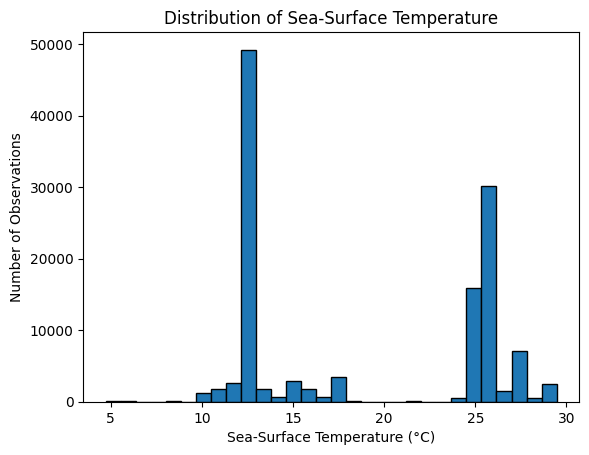

In [24]:
plt.hist(df_sst["sst"], bins=30, edgecolor="black")

plt.title("Distribution of Sea-Surface Temperature")
plt.xlabel("Sea-Surface Temperature (°C)")
plt.ylabel("Number of Observations")

plt.show()

The histogram shows that the SST values are not evenly distributed. There are two clear concentrations of observations, with the largest peak occurring around 12–13°C and another large concentration around 25–26°C. This shows that recorded humpback whale observations are associated with both cooler and warmer sea-surface temperatures. The gap between these concentrations suggests that the SST data may contain distinct groups or patterns, which will be investigated further later in the analysis.

The Second visualisation is of a Box plot showing the spread and potential outliers in SST by season.

In [ ]:
sns.boxplot(data=df_sst, x="season", y="sst",order=season_order)

plt.title("Sea-Surface Temperature by Season")
plt.xlabel("Season")
plt.ylabel("Sea-Surface Temperature (°C)")

plt.show()

The box plot shows clear differences in SST between the four seasons. Winter observations are strongly concentrated around approximately 25°C,with a relatively small spread in the central range of the data.

Spring shows the greatest variation in SST, with a much wider box and range of temperatures than the other seasons. This supports the earlier finding that spring had the highest SST standard deviation.

Summer and autumn have much lower median SST values, both around 12.78°C, and their central values are tightly grouped around this temperature.

The plot therefore shows that recorded humpback whale observations were associated with warmer SST values in winter and generally cooler SST values in summer and autumn.

A number of points appear outside the whiskers for winter, summer and autumn. These are values that are unusual compared with the distribution within each individual season. This does not contradict the earlier overall IQR analysis, which found no outliers when all SST observations were considered together as one dataset.

The Third Graph is looking at the total number of Humpback Whale Observations by season

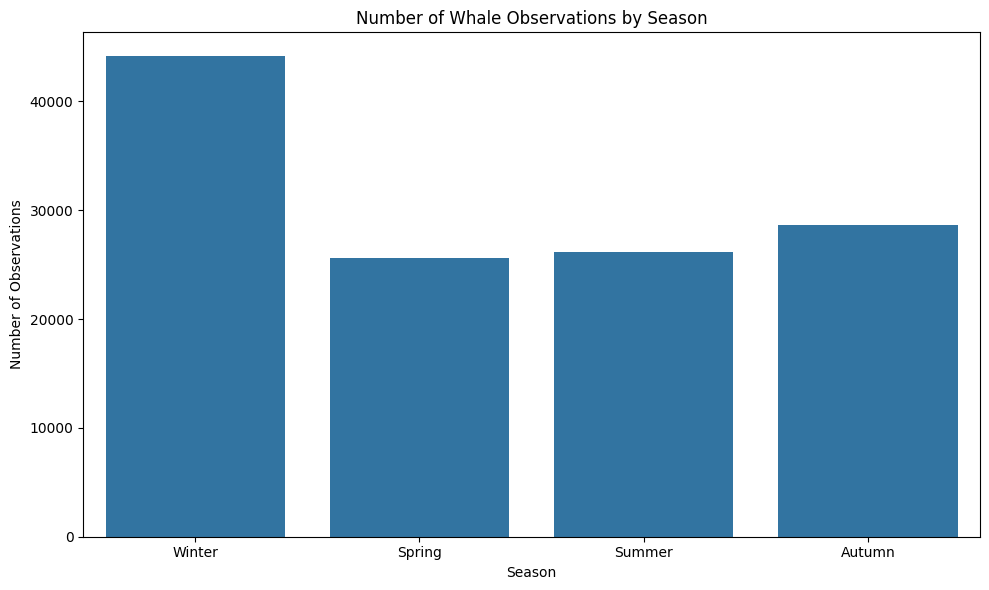

In [28]:
plt.figure(figsize=(10, 6))

sns.countplot( data=df_sst, x="season",order=season_order)

plt.title("Number of Whale Observations by Season")
plt.xlabel("Season")
plt.ylabel("Number of Observations")

plt.tight_layout()
plt.show()

The bar chart shows that the number of recorded humpback whale observations with SST data varies between seasons.

Winter had the highest number of observations, with 38,034 records. Spring had the lowest number of observations, with 23,572 records.

Summer and autumn had similar numbers of observations, with 26,678 observations in summer and 26,024 in autumn.

Overall, the dataset contains noticeably more winter observations than observations from the other seasons.

These counts represent recorded observations rather than the actual number of whales present. Differences between seasons could also be influenced by factors such as observation and reporting effort, so the graph should not be interpreted as evidence that more whales are present during winter.

The fourth Visualisation will be a bar Chart focusing on how the Mean and Median SST vary by season. 

In order to do this, there is code that will enable the calcuation of the mean and median SST by seaso before using matplotlib to plot the graph. 



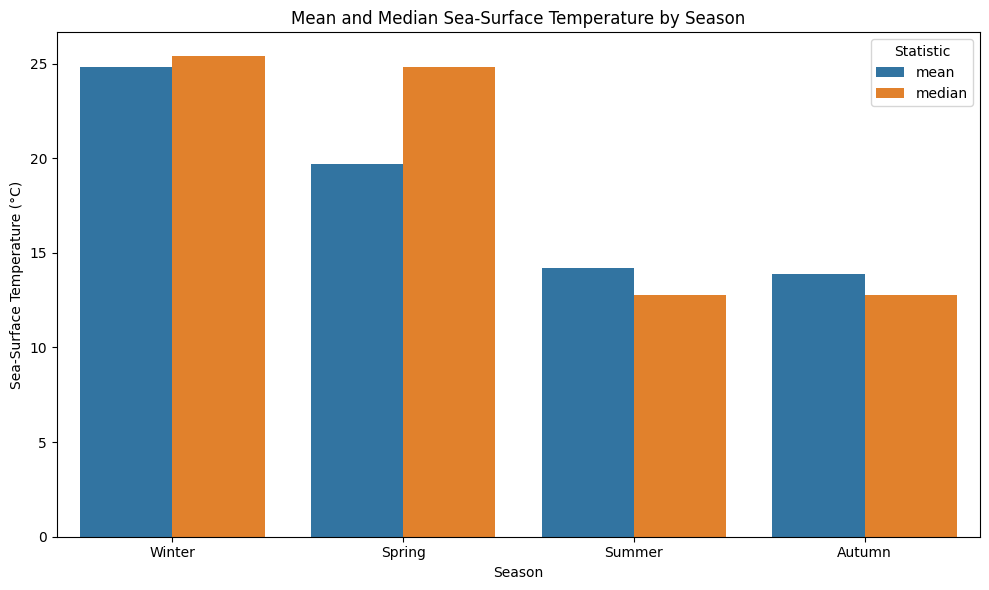

In [29]:
#Calculating the mean and median SST by season
season_sst_summary = (df_sst.groupby("season")["sst"].agg(["mean", "median"]).reindex(season_order)).reset_index()

season_sst_chart = season_sst_summary.melt(id_vars="season",value_vars=["mean", "median"],var_name="statistic",value_name="sst")
#Plotting the graph 
plt.figure(figsize=(10, 6))

sns.barplot(data=season_sst_chart, x="season", y="sst", hue="statistic", order=season_order)

plt.title("Mean and Median Sea-Surface Temperature by Season")
plt.xlabel("Season")
plt.ylabel("Sea-Surface Temperature (°C)")
plt.legend(title="Statistic")

plt.tight_layout()
plt.show()

This graph compares the mean and median SST values for each season.

Winter has the highest mean and median SST, with values of approximately 24.36°C and 25.38°C respectively. This shows that winter observations were generally associated with the warmest sea-surface temperatures.

Spring has lower SST values, with a mean of approximately 19.11°C and a median of 16.92°C. The difference between the mean and median suggests that the spring SST distribution is more spread out.

Summer and autumn have the lowest SST values. Both seasons have a median SST of 12.78°C, while their mean SST values are approximately 14.43°C in summer and 14.05°C in autumn.

Overall, the graph shows a clear seasonal pattern, with higher SST values associated with winter observations and lower SST values associated with summer and autumn observations.

The differences between the mean and median in some seasons also show that the SST values are not distributed evenly, which supports the patterns seen in the earlier histogram and box plot.

Visualisation 5:  Observations by Sea Surface Temperature Range

Calculating the number of observation by sst_range
# Divide SST values into five-degree ranges
df_sst["sst_range"] = pd.cut(
    df_sst["sst"],
    bins=[-5, 0, 5, 10, 15, 20, 25, 30, 35, 40],
    labels=[
        "-5 to 0°C",
        "0 to 5°C",
        "5 to 10°C",
        "10 to 15°C",
        "15 to 20°C",
        "20 to 25°C",
        "25 to 30°C",
        "30 to 35°C",
        "35 to 40°C"
    ],
    include_lowest=True
)
#I was having trouble with the above function and had to consult chatgpt to help me with the syntax.
# Count observations within each SST range
sst_range_counts = (df_sst["sst_range"].value_counts().sort_index().reset_index())

sst_range_counts.columns = ["sst_range","observation_count"]

plt.figure(figsize=(12, 6))

sns.barplot(data=sst_range_counts,x="sst_range",y="observation_count")

plt.title("Whale Observations by Sea-Surface Temperature Range")
plt.xlabel("Sea-Surface Temperature Range")
plt.ylabel("Number of Observations")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---

NOTE

* You may add as many sections as you want, as long as it supports your project workflow.
* All notebook's cells should be run top-down (you can't create a dynamic wherein a given point you need to go back to a previous cell to execute some task, like go back to a previous cell and refresh a variable content)

---

# Push files to Repo

* In cases where you don't need to push files to Repo, you may replace this section with "Conclusions and Next Steps" and state your conclusions and next steps.

In [27]:
# Conclusions and next steps
print("Notebook completed successfully.")
print("Next steps: review the charts and summary statistics, then present the findings.")

Notebook completed successfully.
Next steps: review the charts and summary statistics, then present the findings.
